In [183]:
from sklearn.datasets import load_breast_cancer

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42

### Actividad 1

In [184]:
datos = load_breast_cancer(as_frame=True)
X = datos.data
y = datos.target

print(f"Total de Observaciones: {X.shape[0]} | Variables: {X.shape[1]}")
print("=" * 50)
print(f"Valores faltantes:\n{X.isna().sum()}")
print("=" * 50)
print(f"Variables: {dict(enumerate(datos.target_names))}")

Total de Observaciones: 569 | Variables: 30
Valores faltantes:
mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
dtype: int64
Variables: {0: np.str_('malignant'), 1: np.str_('benig

### Actividad 2

           casos  porcentaje
malignant    212      37.258
benign       357      62.742
Exactitud de un modelo que responde siempre benign - 62.742


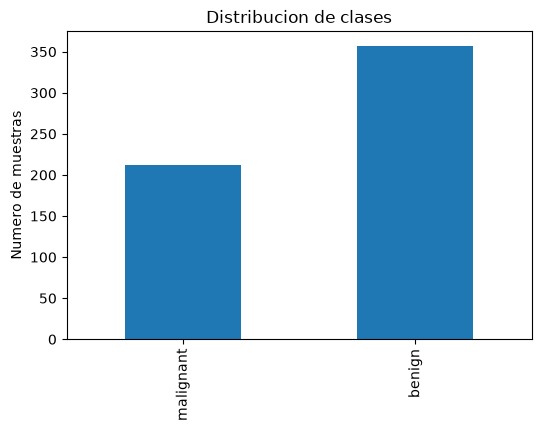

In [185]:
conteo = y.value_counts().sort_index()
conteo.index = datos.target_names

porcentaje = ((conteo / conteo.sum()) * 100).round(3)
resumen = pd.DataFrame({"casos": conteo, "porcentaje": porcentaje})
print(resumen)

mayoritaria = conteo.max() / conteo.sum() * 100
print(f"Exactitud de un modelo que responde siempre {conteo.idxmax()} - {mayoritaria:.3f}")

conteo.plot(kind="bar", figsize=(6, 4))
plt.ylabel("Numero de muestras")
plt.title("Distribucion de clases")
plt.show()

### Actividad 3

In [186]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

_, _, sin_y_train, sin_y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

comparador = pd.DataFrame({
    "conjunto completo": y.value_counts(normalize=True).sort_index(),
    "train (stratificado)": y_train.value_counts(normalize=True).sort_index(),
    "train (sin stratificado)": sin_y_train.value_counts(normalize=True).sort_index(),
    "test (stratificado)": y_test.value_counts(normalize=True).sort_index(),
    "test (sin stratificado)": sin_y_test.value_counts(normalize=True).sort_index()
})

comparador.index = datos.target_names
comparador.head(5)

,conjunto completo,train (stratificado),train (sin stratificado),test (stratificado),test (sin stratificado)
malignant,0.372583,0.373626,0.371429,0.368421,0.377193
benign,0.627417,0.626374,0.628571,0.631579,0.622807


### Actividad 4

In [187]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score


trivial = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
trivial.fit(X_train, y_train)

pred_trivial = trivial.predict(X_test)

print(f"Exactitud: {accuracy_score(y_test, pred_trivial):.5f}")
print(f"Recall sobre la clase benigna (clase 1): {recall_score(y_test, pred_trivial, pos_label=1):.3f}")
print(f"Recall sobre la clase maligna (clase 0): {recall_score(y_test, pred_trivial, pos_label=0):.3f}")

Exactitud: 0.63158
Recall sobre la clase benigna (clase 1): 1.000
Recall sobre la clase maligna (clase 0): 0.000


In [188]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score


def evaluar(modelo, nombre, X_test, y_test):
    preds = modelo.predict(X_test)

    try:
        auc_ = roc_auc_score(y_test, modelo.predict_proba(X_test)[:, 1])
    except:
        auc_ = 0


    return {
        "modelo": nombre,
        "exactitud": accuracy_score(y_test, preds),
        "precision": precision_score(y_test, preds),
        "recall": recall_score(y_test, preds),
        "f1": f1_score(y_test, preds),
        "auc": auc_
    }

resultados = [evaluar(trivial, "Trivial", X_test, y_test)]
pd.DataFrame(resultados)

,modelo,exactitud,precision,recall,f1,auc
0,Trivial,0.631579,0.631579,1.0,0.774194,0.5


### Actividad 5

In [189]:
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

modelo = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

modelo.fit(X_train, y_train)
metricas_escalando = evaluar(modelo, "logistic regresor con escalamiento", X_test, y_test)


In [190]:
modelo_sin_escalar = Pipeline([
    ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

modelo_sin_escalar.fit(X_train, y_train)
metricas_sin_escalar = evaluar(modelo_sin_escalar, "logistic regresor sin escalar", X_test, y_test)

/Users/marcell/Documents/codigo_by_tecsup/datascience-g8/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [191]:
print(f"Exactitud con escalamiento: {metricas_escalando["exactitud"]:.3f}")
print(f"Exactitud sin escalamiento: {metricas_sin_escalar["exactitud"]:.3f}")

print(f"Iteraciones usando escalamiento: {modelo['clf'].n_iter_}")
print(f"Iteraciones sin escalamiento: {modelo_sin_escalar['clf'].n_iter_}")

Exactitud con escalamiento: 0.982
Exactitud sin escalamiento: 0.956
Iteraciones usando escalamiento: [19]
Iteraciones sin escalamiento: [1000]


### Actividad 6

In [192]:
resultados.append(
    evaluar(modelo, "Logistico", X_test, y_test)
)

comparativa = pd.DataFrame(resultados).set_index("modelo")
comparativa["recall_maligna"] = [
    recall_score(y_test, trivial.predict(X_test), pos_label=0),
    recall_score(y_test, modelo.predict(X_test), pos_label=0),
]

mejora_extactidud = comparativa.loc["Logistico", "exactitud"] - comparativa.loc["Trivial", "exactitud"]
mejora_recall = comparativa.loc["Logistico", "recall_maligna"] - comparativa.loc["Trivial", "recall_maligna"]

print(f"Mejora de exactitud: {mejora_extactidud:+.3f}")
print(f"Mejora de recall sobre casos malignos: {mejora_recall:+.3f}")

Mejora de exactitud: +0.351
Mejora de recall sobre casos malignos: +0.976


In [193]:
comparativa

,exactitud,precision,recall,f1,auc,recall_maligna
modelo,,,,,,
Trivial,0.631579,0.631579,1.000000,0.774194,0.50000,0.00000
Logistico,0.982456,0.986111,0.986111,0.986111,0.99537,0.97619


### Actividad 7

Casos con probabilidad entre 0.4 y 0.6: 3
Casos con probabiliades por debajo de 0.05: 36
Casos con probabiliades por encima de 0.95: 54


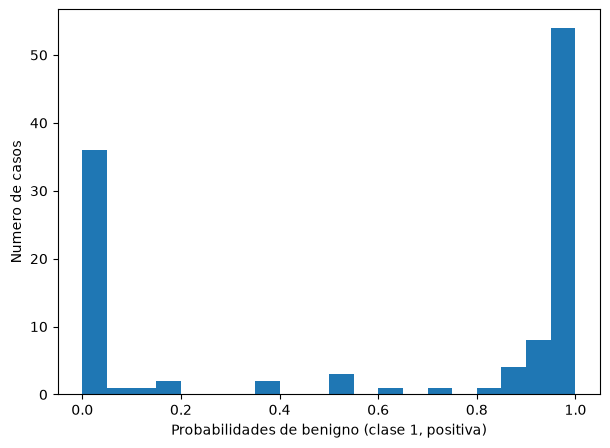

In [194]:
probabilidades = modelo.predict_proba(X_test)[:, 1]
print(
    f"Casos con probabilidad entre 0.4 y 0.6: {((probabilidades > 0.4) & (probabilidades < 0.6)).sum()}"
)
print(
    f"Casos con probabiliades por debajo de 0.05: {(probabilidades < 0.05).sum()}"
)
print(
    f"Casos con probabiliades por encima de 0.95: {(probabilidades > 0.95).sum()}"
)

plt.figure(figsize=(7,5))
plt.hist(probabilidades, bins=20)
plt.xlabel("Probabilidades de benigno (clase 1, positiva)")
plt.ylabel("Numero de casos")
plt.show()

### Actividad 8

In [195]:
probabilidades.shape

(114,)

In [196]:
probabilidades

array([5.88824186e-08, 9.99988665e-01, 6.41082462e-03, 5.33508537e-01,
       6.52500097e-10, 9.92160398e-01, 9.99982825e-01, 5.63527494e-07,
       5.43163692e-05, 8.04184941e-11, 9.89178556e-01, 1.33241870e-03,
       9.98703777e-01, 2.60592467e-05, 2.76224627e-04, 9.01632354e-01,
       3.65861856e-01, 8.34997650e-01, 9.99966119e-01, 9.83017335e-01,
       1.65771925e-03, 5.17399797e-02, 9.99807885e-01, 9.99123324e-01,
       9.90010217e-01, 8.67468162e-01, 4.83595669e-09, 9.90463784e-01,
       9.99169881e-01, 9.98922169e-01, 9.91912973e-01, 9.99989143e-01,
       9.83527366e-01, 9.69239080e-01, 5.37502995e-06, 1.87989311e-01,
       9.98451407e-01, 9.71053325e-01, 6.21262609e-01, 5.44264495e-06,
       9.99944641e-01, 9.99846730e-01, 9.93536689e-01, 2.63830968e-08,
       1.71221909e-03, 7.07218502e-01, 9.99998944e-01, 9.99818581e-01,
       9.30910616e-01, 2.69142775e-04, 9.99617017e-01, 5.46638504e-01,
       9.99381052e-01, 9.08728148e-01, 9.33799774e-01, 9.99328224e-01,
      

In [197]:
(probabilidades >= 0.5).astype(int)

array([0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0,
       0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 1])

In [198]:
decision_manual = (probabilidades >= 0.5).astype(int)
decision_sklearn = modelo.predict(X_test)

print(f"Coincide en todos los casos: {(decision_manual == decision_sklearn).all()}")
print(f"Casos en los que difiere: {(decision_manual != decision_sklearn).sum()}")

Coincide en todos los casos: True
Casos en los que difiere: 0


### Actividad 9

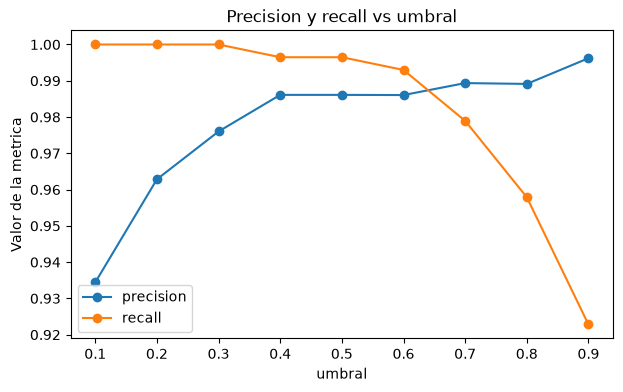

In [199]:
prob_train = modelo.predict_proba(X_train)[:, 1]

filas = []

for umbral in np.arange(0.1, 1.0, 0.1):
    pred_u = (prob_train >= umbral).astype(int)
    filas.append(
        {
            "umbral": round(umbral, 1),
            "marcados_positivos": int(pred_u.sum()),
            "precision": precision_score(y_train, pred_u),
            "recall": recall_score(y_train, pred_u),
            "f1": f1_score(y_train, pred_u)
        }
    )

tabla_umbrales = pd.DataFrame(filas).set_index("umbral")

tabla_umbrales[["precision", "recall"]].plot(figsize=(7, 4), marker="o")
plt.xlabel("umbral")
plt.ylabel("Valor de la metrica")
plt.title("Precision y recall vs umbral")
plt.show()

In [200]:
tabla_umbrales

,marcados_positivos,precision,recall,f1
umbral,,,,
0.1,305,0.934426,1.000000,0.966102
0.2,296,0.962838,1.000000,0.981067
0.3,292,0.976027,1.000000,0.987868
0.4,288,0.986111,0.996491,0.991274
0.5,288,0.986111,0.996491,0.991274
0.6,287,0.986063,0.992982,0.989510
0.7,282,0.989362,0.978947,0.984127
0.8,276,0.989130,0.957895,0.973262
0.9,264,0.996212,0.922807,0.958106


### Actividad 10

Tomando la clase benigna como positiva: VP=71 FP=1 FN=1 VN=41
Casos malignos clasificados como benignos: 1
Caso benigno clasificado como maligno: 1


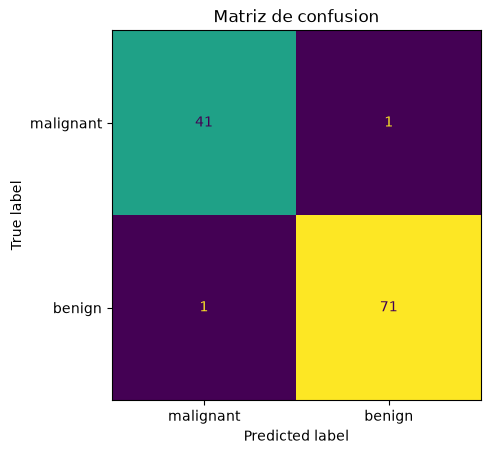

In [201]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

preds = modelo.predict(X_test)
matriz = confusion_matrix(y_test, preds)

vn, fp, fn, vp = matriz.ravel()
print(f"Tomando la clase benigna como positiva: VP={vp} FP={fp} FN={fn} VN={vn}")
print(f"Casos malignos clasificados como benignos: {fp}")
print(f"Caso benigno clasificado como maligno: {fn}")

ConfusionMatrixDisplay.from_estimator(
    modelo, X_test, y_test, display_labels=datos.target_names, colorbar=False
)
plt.title("Matriz de confusion")
plt.show()

### Actividad 11

In [202]:
from sklearn.metrics import classification_report

preds = modelo.predict(X_test)

print(classification_report(y_test, preds, target_names=datos.target_names, digits=4))

              precision    recall  f1-score   support

   malignant     0.9762    0.9762    0.9762        42
      benign     0.9861    0.9861    0.9861        72

    accuracy                         0.9825       114
   macro avg     0.9812    0.9812    0.9812       114
weighted avg     0.9825    0.9825    0.9825       114



### Actividad 12

0.9953703703703703


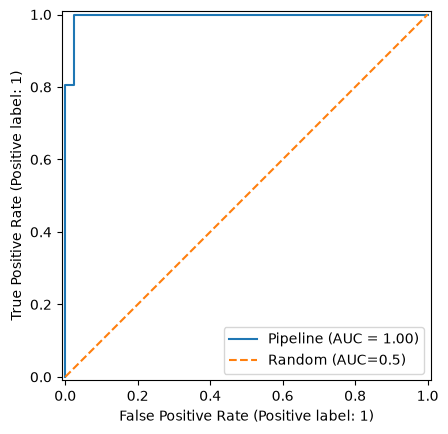

In [203]:
from sklearn.metrics import confusion_matrix, RocCurveDisplay

probabilidades = modelo.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, probabilidades)
print(auc)

RocCurveDisplay.from_estimator(modelo, X_test, y_test)
plt.plot([0, 1], [0, 1], "--", label= "Random (AUC=0.5)")
plt.legend()
plt.show()


### Actividad 13

In [204]:
probabilidades_maligno = modelo.predict_proba(X_test)[:, 0]
y_maligno = (y_test == 0).astype(int)

filas = []
for umbral in np.arange(0.05, 0.96, 0.05):
    marcado = (probabilidades_maligno >= umbral).astype(int)
    m = confusion_matrix(y_maligno, marcado, labels=[0, 1]).ravel()
    vn_c, fp_c, fn_c, vp_c = m
    filas.append({
        "umbral": round(umbral, 2),
        "malignos_detectados": int(vp_c),
        "malignos_perdidos": int(fn_c),
        "revision innecesarias": int(fp_c),
        "precision": precision_score(y_maligno, marcado),
        "recall": recall_score(y_maligno, marcado),
        "coste": fn_c * 20 + fp_c * 1
    })

In [205]:
pd.DataFrame(filas)

,umbral,malignos_detectados,malignos_perdidos,revision innecesarias,precision,recall,coste
0,0.05,42,0,18,0.700000,1.000000,18
1,0.10,41,1,11,0.788462,0.976190,31
2,0.15,41,1,7,0.854167,0.976190,27
3,0.20,41,1,6,0.872340,0.976190,26
4,0.25,41,1,6,0.872340,0.976190,26
5,0.30,41,1,5,0.891304,0.976190,25
6,0.35,41,1,5,0.891304,0.976190,25
7,0.40,41,1,4,0.911111,0.976190,24
8,0.45,41,1,4,0.911111,0.976190,24
9,0.50,41,1,1,0.976190,0.976190,21


### Actividad 14

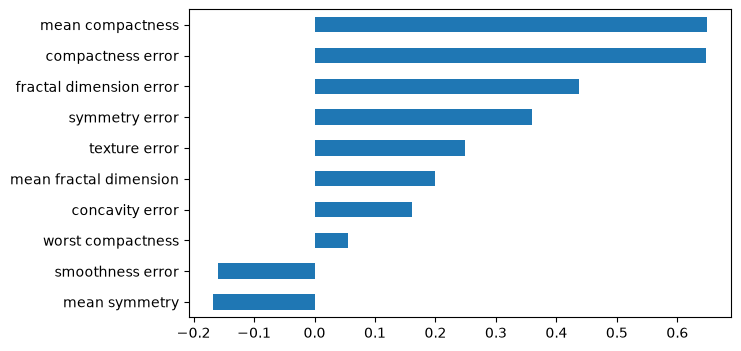

In [206]:
coefs = pd.Series(modelo["clf"].coef_[0], index=X.columns).sort_values()

coefs.tail(10).plot(kind="barh", figsize=(7,4))
plt.show()

In [207]:
# negativa
coefs.head(5)

worst texture          -1.255088
radius error           -1.082965
worst concave points   -0.953686
worst area             -0.947756
worst radius           -0.947616
dtype: float64

In [208]:
# positivas
coefs.tail(5)

texture error              0.248823
symmetry error             0.360492
fractal dimension error    0.437894
compactness error          0.647227
mean compactness           0.648342
dtype: float64

### Actividad 15

In [209]:
filas = []
for c in [0.01, 0.1, 1, 2, 3, 5, 10, 100]:
    m = Pipeline(
        [
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(C=c, max_iter=5000, random_state=RANDOM_STATE))
        ]
    )
    m.fit(X_train, y_train)
    filas.append({
        "C": c,
        "exactitud_train": m.score(X_train, y_train),
        "exactitud_test": m.score(X_test, y_test),
        "suma_abs_coefs": np.abs(m["clf"].coef_).sum()
    })

dff=pd.DataFrame(filas)
dff

,C,exactitud_train,exactitud_test,suma_abs_coefs
0,0.01,0.956044,0.947368,4.032521
1,0.10,0.986813,0.973684,8.830533
2,1.00,0.989011,0.982456,17.250127
3,2.00,0.989011,0.982456,20.655985
4,3.00,0.989011,0.982456,23.114481
5,5.00,0.991209,0.982456,26.984287
6,10.00,0.991209,0.964912,33.951034
7,100.00,0.993407,0.947368,94.242559


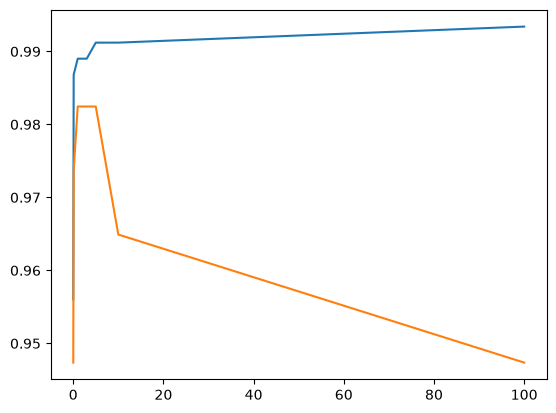

In [210]:
plt.plot(dff["C"], dff["exactitud_train"])
plt.plot(dff["C"], dff["exactitud_test"])

### Actividad 16

In [211]:
from sklearn.neighbors import KNeighborsClassifier

filas = []
knn = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=3))
knn.fit(X_train, y_train)
resultados.append(evaluar(knn, "KNN(10)", X_test, y_test))

pd.DataFrame(resultados)

,modelo,exactitud,precision,recall,f1,auc
0,Trivial,0.631579,0.631579,1.000000,0.774194,0.500000
1,Logistico,0.982456,0.986111,0.986111,0.986111,0.995370
2,KNN(10),0.982456,0.972973,1.000000,0.986301,0.983466


In [212]:
set(knn.predict_proba(X_test[:3])[:, 1])

{np.float64(0.0), np.float64(1.0)}

### Actividad 17

In [213]:
filas = []

for k in [1, 3, 5, 10, 20, 50]:
    m = make_pipeline(
        StandardScaler(),
        KNeighborsClassifier(n_neighbors=k)
    )
    m.fit(X_train, y_train)
    filas.append({
        "k": k,
        "exactitud_train": m.score(X_train, y_train),
        "exactitud_test": m.score(X_test, y_test)
    })

dff = pd.DataFrame(filas).set_index("k")
dff

,exactitud_train,exactitud_test
k,,
1,1.000000,0.938596
3,0.978022,0.982456
5,0.973626,0.956140
10,0.975824,0.964912
20,0.969231,0.973684
50,0.949451,0.947368


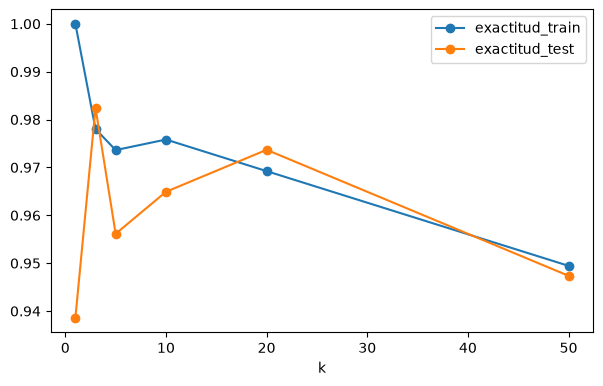

In [214]:
dff.plot(marker="o", figsize=(7, 4.2))
plt.show()

### Actividad 18

In [215]:
from sklearn.neighbors import KNeighborsClassifier

filas = []
knn_sin_escalar = make_pipeline(KNeighborsClassifier(n_neighbors=10))
knn_sin_escalar.fit(X_train, y_train)

comparacion = pd.DataFrame([
    evaluar(knn, "con escalado", X_test, y_test),
    evaluar(knn_sin_escalar, "sin escalar",  X_test, y_test)
])

pd.DataFrame(comparacion)

,modelo,exactitud,precision,recall,f1,auc
0,con escalado,0.982456,0.972973,1.000000,0.986301,0.983466
1,sin escalar,0.929825,0.944444,0.944444,0.944444,0.958664


In [216]:
X_train.std().sort_values(ascending=False)

worst area                 552.926912
mean area                  344.944564
area error                  41.763197
worst perimeter             33.195053
mean perimeter              24.149231
worst texture                6.225470
worst radius                 4.770020
mean texture                 4.405291
mean radius                  3.499380
perimeter error              1.973475
texture error                0.571523
radius error                 0.267825
worst concavity              0.215937
worst compactness            0.159882
mean concavity               0.081747
worst concave points         0.066784
worst symmetry               0.064624
mean compactness             0.053522
mean concave points          0.038925
concavity error              0.032370
mean symmetry                0.028074
worst smoothness             0.022550
compactness error            0.018467
worst fractal dimension      0.018408
mean smoothness              0.013458
symmetry error               0.008764
mean fractal

### Actividad 19

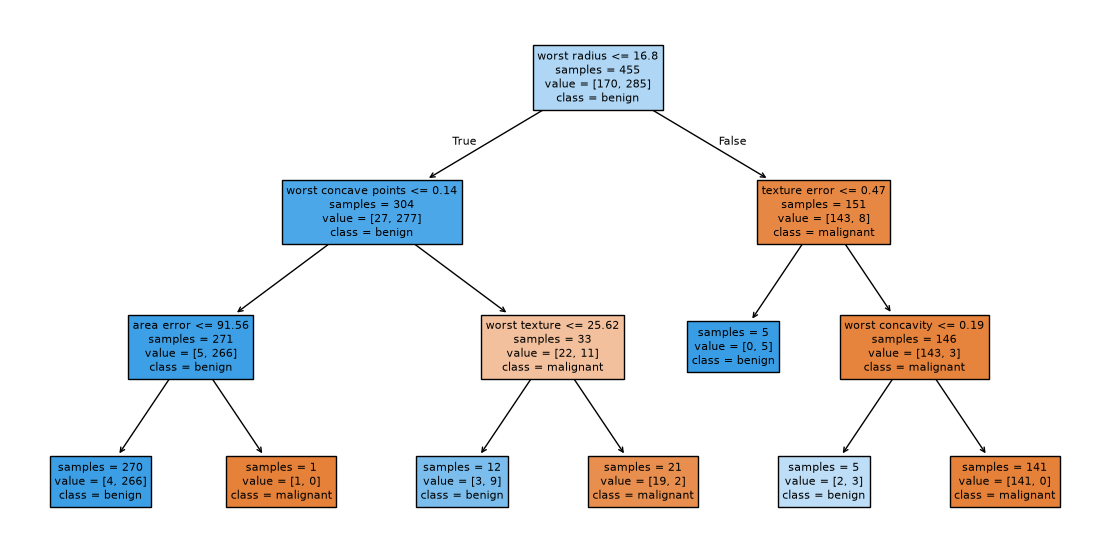

In [217]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

arbol3 = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE)
arbol3.fit(X_train, y_train)

plt.figure(figsize=(14, 7))
plot_tree(arbol3, feature_names=list(X.columns), class_names=list(datos.target_names),
          filled=True, impurity=False, precision=2)
plt.show()

In [218]:

arbol3_escalado = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE))
]
)
arbol3_escalado.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](30,)","['mean radius','mean texture','mean perimeter',...,'worst concave points', 'worst symmetry','worst fractal dimension']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,30
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


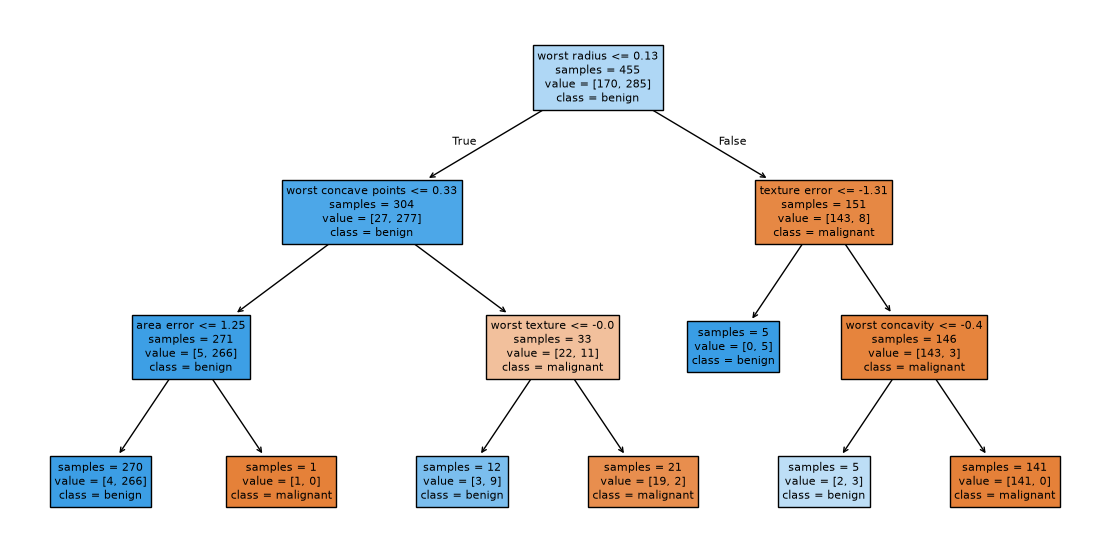

In [219]:
plt.figure(figsize=(14, 7))
plot_tree(arbol3_escalado["clf"], feature_names=list(X.columns), class_names=list(datos.target_names),
          filled=True, impurity=False, precision=2)
plt.show()

In [220]:
(arbol3.predict(X_test) == arbol3_escalado.predict(X_test)).all()

np.True_

### Actividad 20

In [221]:
filas = []
for profundidad in [1, 2, 3, 5, 8, None]:
    m = DecisionTreeClassifier(
        max_depth=profundidad,
        random_state=RANDOM_STATE
    )
    m.fit(X_train, y_train)
    filas.append({
        "max_depth": profundidad,
        "exactitud_train": m.score(X_train, y_train),
        "exactitud_test": m.score(X_test, y_test),
        "n_hojas": m.get_n_leaves()
    })

dff = pd.DataFrame(filas).set_index("max_depth")
dff

,exactitud_train,exactitud_test,n_hojas
max_depth,,,
1.0,0.923077,0.921053,2
2.0,0.958242,0.894737,4
3.0,0.975824,0.938596,7
5.0,0.993407,0.921053,15
8.0,1.000000,0.912281,19
NaN,1.000000,0.912281,19


### Actividad 21

In [222]:
filas = []
for semilla in range(5):
    # print(semilla)
    muestra = X_train.sample(frac=0.9, random_state=semilla)
    a = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE)
    a.fit(muestra, y_train.loc[muestra.index])
    filas.append(
        {
            "semilla": semilla,
            "variable_primer_corte": X.columns[a.tree_.feature[0]],
            "umbral": round(a.tree_.threshold[0], 3)
        }
    )

pd.DataFrame(filas).set_index("semilla")

,variable_primer_corte,umbral
semilla,,
0,worst area,884.750
1,mean concave points,0.049
2,mean concave points,0.051
3,worst radius,16.795
4,worst radius,16.795


### Actividad 22

In [223]:
m = DecisionTreeClassifier(
    max_depth=3,
    random_state=RANDOM_STATE
)
m.fit(X_train, y_train)

resultados.append(evaluar(m, "Decision Tree (3)", X_test, y_test))

In [224]:
from sklearn.ensemble import RandomForestClassifier

bosque = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE
)

bosque.fit(X_train, y_train)
resultados.append(evaluar(bosque, "Random Forest", X_test, y_test))

pd.DataFrame(resultados)
# 3.0 0.938596

,modelo,exactitud,precision,recall,f1,auc
0,Trivial,0.631579,0.631579,1.000000,0.774194,0.500000
1,Logistico,0.982456,0.986111,0.986111,0.986111,0.995370
2,KNN(10),0.982456,0.972973,1.000000,0.986301,0.983466
3,Decision Tree (3),0.938596,0.945205,0.958333,0.951724,0.944610
4,Random Forest,0.947368,0.958333,0.958333,0.958333,0.993717


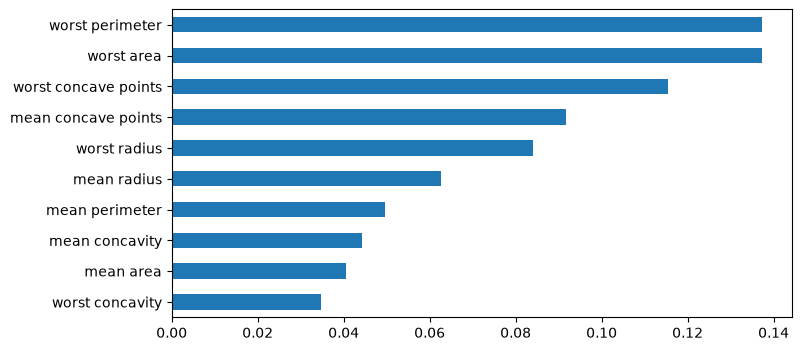

In [225]:
importancias = pd.Series(bosque.feature_importances_, index=X.columns).sort_values()
importancias.tail(10).plot(kind="barh", figsize=(8, 4))
plt.show()

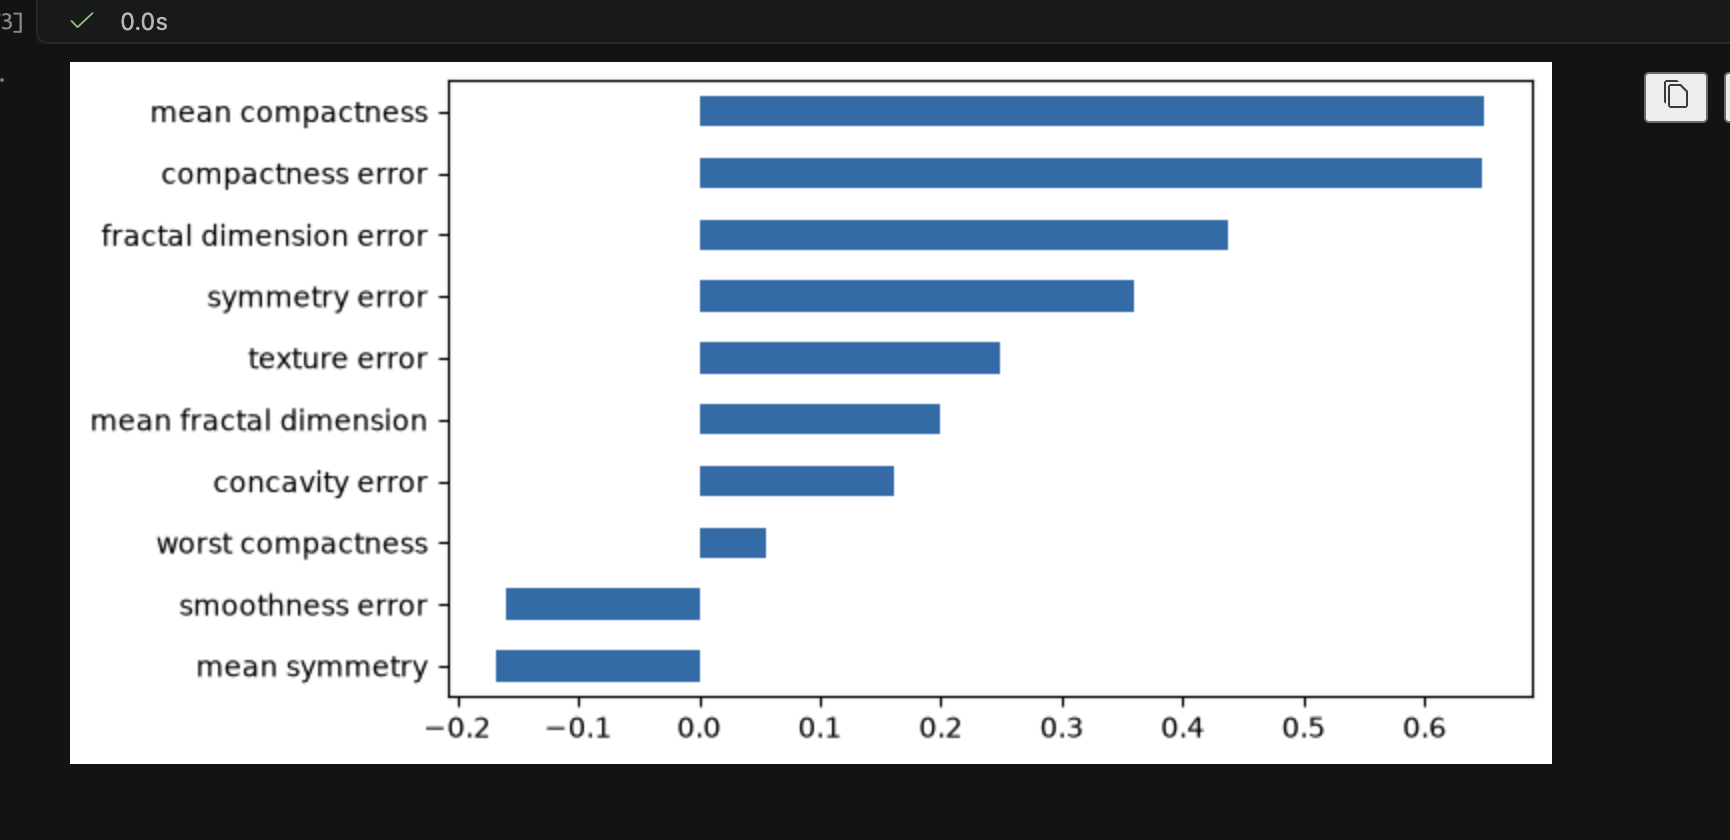

### Actividad 23

In [226]:
filas = []
for n in [10, 20, 30, 40, 50, 100, 300, 500, 1000]:
    m = RandomForestClassifier(n_estimators=n, random_state=RANDOM_STATE)
    m.fit(X_train, y_train)
    filas.append({
        "n_estimators": n,
        "exactitud_train": m.score(X_train, y_train),
        "exactitud_test": m.score(X_test, y_test)
    })

pd.DataFrame(filas).set_index("n_estimators")

,exactitud_train,exactitud_test
n_estimators,,
10,0.995604,0.938596
20,1.000000,0.956140
30,1.000000,0.947368
40,1.000000,0.947368
50,1.000000,0.956140
100,1.000000,0.956140
300,1.000000,0.947368
500,1.000000,0.956140
1000,1.000000,0.956140


### Actividad 24

In [227]:
from sklearn.ensemble import HistGradientBoostingClassifier

boosting = HistGradientBoostingClassifier(
    random_state=RANDOM_STATE,
    max_iter=500
)

boosting.fit(X_train, y_train)

resultados.append(evaluar(boosting,"Boosting", X_test, y_test))

pd.DataFrame(resultados)

,modelo,exactitud,precision,recall,f1,auc
0,Trivial,0.631579,0.631579,1.000000,0.774194,0.500000
1,Logistico,0.982456,0.986111,0.986111,0.986111,0.995370
2,KNN(10),0.982456,0.972973,1.000000,0.986301,0.983466
3,Decision Tree (3),0.938596,0.945205,0.958333,0.951724,0.944610
4,Random Forest,0.947368,0.958333,0.958333,0.958333,0.993717
5,Boosting,0.973684,0.960000,1.000000,0.979592,0.990741


### Actividad 25

In [ ]:
from sklearn.linear_model import Perceptron

perceptron = make_pipeline(
    StandardScaler(),
    Perceptron(random_state=42)
)

perceptron.fit(X_train, y_train)
resultados.append(
    evaluar(perceptron, "Perceptron", X_test, y_test)
)

In [229]:
pd.DataFrame(resultados)

,modelo,exactitud,precision,recall,f1,auc
0,Trivial,0.631579,0.631579,1.000000,0.774194,0.500000
1,Logistico,0.982456,0.986111,0.986111,0.986111,0.995370
2,KNN(10),0.982456,0.972973,1.000000,0.986301,0.983466
3,Decision Tree (3),0.938596,0.945205,0.958333,0.951724,0.944610
4,Random Forest,0.947368,0.958333,0.958333,0.958333,0.993717
5,Boosting,0.973684,0.960000,1.000000,0.979592,0.990741
6,Perceptron,0.956140,0.985507,0.944444,0.964539,0.000000


### Actividad 26

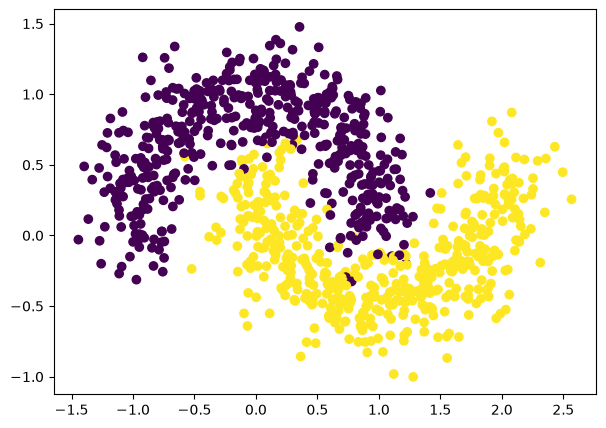

In [242]:
from sklearn.datasets import make_moons

X_moons, y_moons = make_moons(n_samples=1000, noise=0.2, random_state=RANDOM_STATE)
Xm_train, Xm_test, ym_train, ym_test = train_test_split(
    X_moons, y_moons, test_size=0.2, stratify=y_moons
)

plt.figure(figsize=(7,5))
plt.scatter(X_moons[:,0], X_moons[:,1], c=y_moons)
plt.show()

In [232]:
from sklearn.neural_network import MLPClassifier

In [245]:
perceptron_ex = []
mlp_ex = []

for _ in range(20):
    Xm_train, Xm_test, ym_train, ym_test = train_test_split(
        X_moons, y_moons, test_size=0.2, stratify=y_moons
    )

    perceptron_moons = make_pipeline(
        StandardScaler(),
        Perceptron(random_state=RANDOM_STATE)
    )
    perceptron_moons.fit(Xm_train, ym_train)

    mlp_moons = make_pipeline(
        StandardScaler(),
        MLPClassifier(hidden_layer_sizes=(16,), max_iter=3000, random_state=RANDOM_STATE)
    )

    mlp_moons.fit(Xm_train, ym_train)

    perceptron_ex.append(perceptron_moons.score(Xm_test, ym_test))
    mlp_ex.append(mlp_moons.score(Xm_test, ym_test))


print(f"Perceptron: {sum(perceptron_ex) / len(perceptron_ex):.3f}")
print(f"MLP: {sum(mlp_ex) / len(mlp_ex):.3f}")

Perceptron: 0.831
MLP: 0.969


### Actividad 27

In [255]:
red = make_pipeline(
    StandardScaler(),
    MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=2000, random_state=RANDOM_STATE)
)

red.fit(X_train, y_train)
resultados.append(evaluar(red, "MLP (64,32)", X_test, y_test))

In [256]:
pd.DataFrame(resultados)

,modelo,exactitud,precision,recall,f1,auc
0,Trivial,0.631579,0.631579,1.000000,0.774194,0.500000
1,Logistico,0.982456,0.986111,0.986111,0.986111,0.995370
2,KNN(10),0.982456,0.972973,1.000000,0.986301,0.983466
3,Decision Tree (3),0.938596,0.945205,0.958333,0.951724,0.944610
4,Random Forest,0.947368,0.958333,0.958333,0.958333,0.993717
5,Boosting,0.973684,0.960000,1.000000,0.979592,0.990741
6,Perceptron,0.956140,0.985507,0.944444,0.964539,0.000000
7,MLP,0.956140,0.985507,0.944444,0.964539,0.993386
8,MLP (64),0.956140,0.985507,0.944444,0.964539,0.993717
9,"MLP (64,32)",0.964912,0.985714,0.958333,0.971831,0.993717


In [259]:
red_sin_escalar = make_pipeline(
    MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=2000, random_state=RANDOM_STATE)
)

red_sin_escalar.fit(X_train, y_train)
resultados.append(evaluar(red_sin_escalar, "MLP (64,32) sin escalar", X_test, y_test))

In [260]:
pd.DataFrame(resultados)

,modelo,exactitud,precision,recall,f1,auc
0,Trivial,0.631579,0.631579,1.000000,0.774194,0.500000
1,Logistico,0.982456,0.986111,0.986111,0.986111,0.995370
2,KNN(10),0.982456,0.972973,1.000000,0.986301,0.983466
3,Decision Tree (3),0.938596,0.945205,0.958333,0.951724,0.944610
4,Random Forest,0.947368,0.958333,0.958333,0.958333,0.993717
5,Boosting,0.973684,0.960000,1.000000,0.979592,0.990741
6,Perceptron,0.956140,0.985507,0.944444,0.964539,0.000000
7,MLP,0.956140,0.985507,0.944444,0.964539,0.993386
8,MLP (64),0.956140,0.985507,0.944444,0.964539,0.993717
9,"MLP (64,32)",0.964912,0.985714,0.958333,0.971831,0.993717


### Actividad 28

In [264]:
from sklearn.svm import SVC

svm_lineal = make_pipeline(
    StandardScaler(), SVC(kernel="linear", probability=True, random_state=RANDOM_STATE)
)

svm_lineal.fit(X_train, y_train)

svm_rbf = make_pipeline(
    StandardScaler(), SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE)
)

svm_rbf.fit(X_train, y_train)

resultados.append(evaluar(svm_lineal, "svm lineal", X_test, y_test))
resultados.append(evaluar(svm_rbf, "svm rbf", X_test, y_test))

/Users/marcell/Documents/codigo_by_tecsup/datascience-g8/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/marcell/Documents/codigo_by_tecsup/datascience-g8/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


In [265]:
pd.DataFrame(resultados)

,modelo,exactitud,precision,recall,f1,auc
0,Trivial,0.631579,0.631579,1.000000,0.774194,0.500000
1,Logistico,0.982456,0.986111,0.986111,0.986111,0.995370
2,KNN(10),0.982456,0.972973,1.000000,0.986301,0.983466
3,Decision Tree (3),0.938596,0.945205,0.958333,0.951724,0.944610
4,Random Forest,0.947368,0.958333,0.958333,0.958333,0.993717
5,Boosting,0.973684,0.960000,1.000000,0.979592,0.990741
6,Perceptron,0.956140,0.985507,0.944444,0.964539,0.000000
7,MLP,0.956140,0.985507,0.944444,0.964539,0.993386
8,MLP (64),0.956140,0.985507,0.944444,0.964539,0.993717
9,"MLP (64,32)",0.964912,0.985714,0.958333,0.971831,0.993717


In [268]:
filas = []

for c in [0.01, 1, 100]:
    m = make_pipeline(StandardScaler(), SVC(C=c, random_state=RANDOM_STATE, kernel="rbf"))
    m.fit(X_train, y_train)
    filas.append({
        "C": c,
        "exactitud_train": m.score(X_train, y_train),
        "exactitud_test": m.score(X_test, y_test)
    })

pd.DataFrame(filas)

,C,exactitud_train,exactitud_test
0,0.01,0.626374,0.631579
1,1.00,0.982418,0.982456
2,100.00,1.000000,0.947368


### Actividad 29

In [270]:
from sklearn.naive_bayes import GaussianNB

naive = GaussianNB().fit(X_train, y_train)
resultados.append(evaluar(naive, "Naive Bayes", X_test, y_test))

pd.DataFrame(resultados)

,modelo,exactitud,precision,recall,f1,auc
0,Trivial,0.631579,0.631579,1.000000,0.774194,0.500000
1,Logistico,0.982456,0.986111,0.986111,0.986111,0.995370
2,KNN(10),0.982456,0.972973,1.000000,0.986301,0.983466
3,Decision Tree (3),0.938596,0.945205,0.958333,0.951724,0.944610
4,Random Forest,0.947368,0.958333,0.958333,0.958333,0.993717
5,Boosting,0.973684,0.960000,1.000000,0.979592,0.990741
6,Perceptron,0.956140,0.985507,0.944444,0.964539,0.000000
7,MLP,0.956140,0.985507,0.944444,0.964539,0.993386
8,MLP (64),0.956140,0.985507,0.944444,0.964539,0.993717
9,"MLP (64,32)",0.964912,0.985714,0.958333,0.971831,0.993717


### Actividad 30

### Actividad 31

In [271]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
candidatos = {
    "logistica": modelo,
    "SVM (RBF)": svm_rbf,
    "Boosting": boosting,
    "RF": bosque
}

filas = []
for nombre, estimador in candidatos.items():
    scores = cross_val_score(estimador, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
    filas.append({
        "modelo": nombre,
        "auc_medio": scores.mean(),
        "desviacion": scores.std()
    })

pd.DataFrame(filas).set_index("modelo")

/Users/marcell/Documents/codigo_by_tecsup/datascience-g8/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/marcell/Documents/codigo_by_tecsup/datascience-g8/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/marcell/Documents/codigo_by_tecsup/datascience-g8/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/marcell/Documents/cod

,auc_medio,desviacion
modelo,,
logistica,0.995872,0.004960
SVM (RBF),0.995562,0.004758
Boosting,0.995459,0.003033
RF,0.990402,0.007171


### Actividad 32

### Actividad 33

### Actividad 34